In [11]:
import os
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.store.memory import BaseStore,InMemoryStore
from langchain_core.runnables import RunnableConfig
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langchain_huggingface import HuggingFaceEmbeddings,HuggingFaceEndpointEmbeddings
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from typing import TypedDict,Annotated,List
import uuid
load_dotenv()


True

In [4]:
model=ChatGroq(model="openai/gpt-oss-120b",temperature=0.2,api_key=os.getenv("GROQ_API_KEY"))

In [5]:
Store=InMemoryStore()

In [8]:
class MemoryDecision(BaseModel):
    should_write:bool=Field(description='wheather is should write into memory or not')
    memories:List[str]=Field(default_factory=list,description="it is write on memories")

In [9]:
extractor_llm=model

In [10]:
memory_extractor=extractor_llm.with_structured_output(MemoryDecision)

In [13]:
def remember_only_node(state:MessagesState,config:RunnableConfig,store=BaseStore):
    
    user_id=config['configurable']['user_id']

    user_details=("user",user_id,"details")

    last_msg=state['messages'][-1].content

    decision:MemoryDecision=memory_extractor.invoke(
        [SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},]
    )
    
    if decision.should_write:
        for mem in decision.memories:
            store.put(user_details,str(uuid.uuid4()),{"data":mem})

    return {"messages":AIMessage(content="noted")}




In [14]:
builder=StateGraph(MessagesState)
builder.add_node("remember_only",remember_only_node)
builder.add_edge(START,"remember_only")
builder.add_edge("remember_only",END)

graph=builder.compile(store=Store)

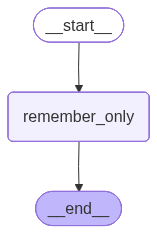

In [15]:
graph

In [16]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="hi my name is rahul")]},config=config)

result['messages'][-1].content

'noted'

In [17]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="i love python")]},config=config)

result['messages'][-1].content

'noted'

In [20]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="what is gen")]},config=config)

result['messages'][-1].content

'noted'

In [ ]:
item=Store.search(("user","u1","details"))

for it in item:
    print(it.value['data'])

User's name is Rahul.
User loves Python.


# cretaing the new memories without duplication

In [32]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [33]:
class MemoryDecision(BaseModel):
    should_write:str=Field(description="wheather it should write or not ")
    memories:List[MemoryItem]=Field(default_factory=List,description="into memories")

In [34]:
memory_extractor=extractor_llm.with_structured_output(MemoryDecision)

In [35]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [36]:
Store=InMemoryStore()

In [38]:
def chat_only_node(state:MessagesState,config:RunnableConfig,store=BaseStore):
    
    user_id=config['configurable']['user_id']

    namespace=("user",user_id,"details")

    last_msg=state['messages'][-1].content

    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"


    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_msg}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

    


  
    



In [40]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat",chat_only_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=Store)

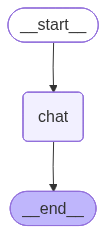

In [41]:
graph

In [42]:
config = {"configurable": {"user_id": "u1"}}

In [46]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Nitish"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [47]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [48]:
for it in Store.search(("user", "u1", "details")):
    print(it.value['data'])

The user's name is Nitish.
The user likes Python for programming.
